# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [1]:
using LinearAlgebra
using Plots
using Plots.Measures
using Statistics
using Distributions

In [ ]:
function jacobi(A, b, x0, ϵ; max_iter = 1000, boolean = false)
    n = length(b)
    x = copy(x0)
    x_new = similar(x)

    for k in 1:max_iter
        for i in 1:n
            sig = 0.0
            for j in 1:n
                if j != i
                    sig = sig + A[i, j] * x[j]
                end
            end
            x_new[i] = (b[i] - sig)/A[i, i]
        end

        # Criterio de convergencia residuo
        if norm(A*x_new -b) < ϵ
            if boolean
                return true
            end
            return x_new, k
        end

        x .= x_new
    end

    return false
end

jacobi (generic function with 1 method)

In [66]:
function gauss_seidel(A, b, x0, ϵ; max_iter = 1000, boolean = false)
    n = length(b)
    x = copy(x0)
    
    for k in 1:max_iter
        for i in 1:n
            sig = 0.0
            for j in 1:n
                if j != i
                    sig += A[i, j] * x[j]
                end
            end
            x[i] = (b[i] - sig)/A[i, i]
        end

        # Criterio de convergencia residuo
        if norm(A*x -b) < ϵ
            if boolean
                return true
            end
            return x, k
        end
    end

    return false
    
end

gauss_seidel (generic function with 1 method)

Qual deveria ser a complexidade computacional do código que você escreveu?

de forma intuitiva temos um while, dentro dele um for e dentro dele outro for, nos dois for realizamos operações "basicas" que numa analise assintotica não são consideradas então poderiamos dizer que tanto para jacobi como para gauss_seidel a complexidade é $O(n^2)$ a diferença é no while, chamemos de $k_j$ o numero de vezes que jacobi roda o while ate alcançar $\epsilon$ e $k_{gs}$ o numero de vezes que gauss seidel roda o while ate alcançar $\epsilon$, assim eles tem complexidade:

jacobi: $O(k_j \cdot n^2)$

gauss-seidel: $O(k_{gs} \cdot n^2)$

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [5]:
# Dados para o grafico
A1 = [2 1;
      5 7]

x01 = [0.0, 0.0]
b1 = [11, 13]

A2 = [7 2 4;
      1 4 2;
      1 0 3]

b2 = [23, 29, 11]
x02 = [0.0, 0.0, 0.0]

x = range(10^(-1), 10^(-99), 1000)
y_j = last.(jacobi.(Ref(A1), Ref(b1), Ref(x01), x))
y_gs = last.(gauss_seidel.(Ref(A1), Ref(b1), Ref(x01), x))

y_j1 = last.(jacobi.(Ref(A2), Ref(b2), Ref(x02), x))
y_gs1 = last.(gauss_seidel.(Ref(A2), Ref(b2), Ref(x02), x))
print()

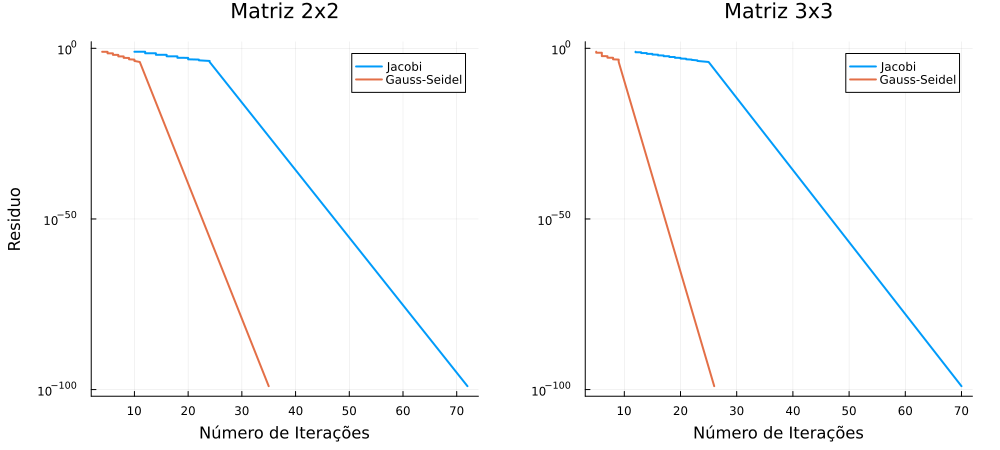

In [6]:
# Código gerando gráficos
p1 = plot(y_j, x, 
     yscale=:log10, 
     label="Jacobi", 
     lw=2, 
     xlabel="Número de Iterações",
     ylabel="Residuo",
     title="Matriz 2x2")

plot!(y_gs, x, 
      yscale=:log10, 
      label="Gauss-Seidel", 
      lw=2,
      )

p2 = plot(y_j1, x, 
     yscale=:log10, 
     label="Jacobi", 
     lw=2, 
     xlabel="Número de Iterações",
     title="Matriz 3x3")

plot!(y_gs1, x, 
      yscale=:log10, 
      label="Gauss-Seidel", 
      lw=2,
      )

plot(p1, p2, layout = (1, 2), size=(1000, 450), margin=5mm)

In [7]:
println("Para a matriz 2x2:", A1," Gauss-Seidel é, em media, " , mean(y_j ./ y_gs), " melhor em numero de iterações do que jacobi")
println("Para a matriz 3x3:", A2," Gauss-Seidel é, em media, " , mean(y_j1 ./ y_gs1), " melhor em numero de iterações do que jacobi")

Para a matriz 2x2:[2 1; 5 7] Gauss-Seidel é, em media, 2.40830404040404 melhor em numero de iterações do que jacobi
Para a matriz 3x3:[7 2 4; 1 4 2; 1 0 3] Gauss-Seidel é, em media, 2.4505212759462753 melhor em numero de iterações do que jacobi


Por velocidade entendo como quantidade de repetições ate que o algotimo, se convergir, atinja o $\epsilon$ desejado.

De acordo com os graficos realizados acima para matrizes 2x2 e 3x3 com valores inteiros o algoritmo de gauss seidel sempre converge mais rapido, em media gauss seidel é aproximadamente 2.5 vezes mais rapido do que jacobi, o que intuitivamente faz sentido pois gauss-seidel utiliza os valores atualizados para calcular novos $x_i$

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [38]:
# Dados para o grafico
s = 100
ϵ = 1e-10
intervalo = 2:s
y_j2 = []
y_gs2 = []

for m in intervalo
    A = rand(m,m)
    b = rand(m)
    x0 = zeros(m)

    push!(y_j2, jacobi(A, b, x0, ϵ))
    push!(y_gs2, gauss_seidel(A, b, x0, ϵ))
end

In [39]:
@show y_j2
@show y_gs2
print()

y_j2 = Any[([-0.8875034861666917, 3.555712427866838], 38), false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false]
y_gs2 = Any[([-0.8875034864429874, 3.555712428059747], 20), false, ([1.4021567690641772, 0.17917361992924896, -0.24642633890458987, -1.0992900424719148], 134), false, false, false, false, false, false, false, false, false, false, false, false, false, fals

Vimos em sala de aula que se uma matriz for diagonal dominante o metodo de jacobi converge, porem é dificil que matrizes rand(m, m) sejam diagonais dominantes pois cada entrada possui um valor aleatorio de 0 a 1, a distribuicao é uniforme logo todos os valores tem a mesma probabilidade então é muito improvavel que apareça uma matriz diagonal dominante, claro se a matriz não for fiagonal domiante ela ainda poderia convergir baixo outros criterios que não consigo detalhar porem como vemos acima para jacobi e gauss-saidel esses outros criterios para matrizes rand(m, m) são bastante improvaveis , testamos para matrizes 2x2 ate 100x100 repetindo ate converger a um epsilon pequeno (1e-10) ou ate realizar 1000 iterações.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [399]:
ϕ(x) = cdf(Normal(0,1), x)

c =quantile(Normal(0,1), 0.90)
c

1.2815515655446004

In [440]:
function converge_pra_(m, residuo, c)
    A = randn(m,m) + (c*sqrt(m))*I
    b = randn(m)
    x0 = zeros(m)
    return jacobi(A, b, x0, residuo, boolean=true, max_iter=1000)
end


converge_pra_ (generic function with 2 methods)

In [436]:
for x in 1:0.01:2
    println(x)
end

1.0
1.01
1.02
1.03
1.04
1.05
1.06
1.07
1.08
1.09
1.1
1.11
1.12
1.13
1.14
1.15
1.16
1.17
1.18
1.19
1.2
1.21
1.22
1.23
1.24
1.25
1.26
1.27
1.28
1.29
1.3
1.31
1.32
1.33
1.34
1.35
1.36
1.37
1.38
1.39
1.4
1.41
1.42
1.43
1.44
1.45
1.46
1.47
1.48
1.49
1.5
1.51
1.52
1.53
1.54
1.55
1.56
1.57
1.58
1.59
1.6
1.61
1.62
1.63
1.64
1.65
1.66
1.67
1.68
1.69
1.7
1.71
1.72
1.73
1.74
1.75
1.76
1.77
1.78
1.79
1.8
1.81
1.82
1.83
1.84
1.85
1.86
1.87
1.88
1.89
1.9
1.91
1.92
1.93
1.94
1.95
1.96
1.97
1.98
1.99
2.0


In [ ]:
m = 100, k = 1.0997

In [ ]:
total = 0

linspace = 1:0.01:2

for x in linspace
    total = 0
    for k in 1:1000
        if converge_pra_(13, 1e-10, x) == false
            total+= 1
        end
    end
    if total/1000 > 0.95
        print(x)
        break
    end
end
print(total)

0

In [407]:
s1 = 100 # matrizes 
s2 = 10 # numero de matrizes
ϵ = 1e-6

intervalo1 = 2:s1
intervalo2 = 1:s2

sucess_history_j = []
sucess_history_gs = []


for m in intervalo1
    epoch_sucess_j = 0
    epoch_sucess_gs = 0

    for k in intervalo2
        A = rand(m,m) + (sqrt(m))*I
        b = rand(m)
        x0 = zeros(m)

        epoch_sucess_gs += gauss_seidel(A, b, x0, ϵ, boolean=true)
        epoch_sucess_j += jacobi(A, b, x0, ϵ, boolean=true, max_iter=5000)
    end 

    push!(sucess_history_j, epoch_sucess_j/s2)
    push!(sucess_history_gs, epoch_sucess_gs/s2)
end

In [86]:
@show sucess_history_gs
print()

sucess_history_gs = Any[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


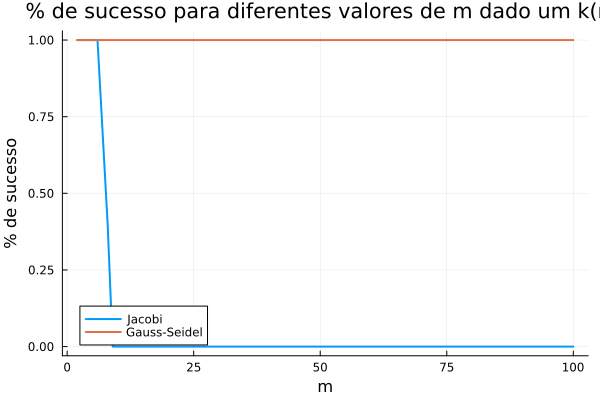

In [408]:
p1 = plot( intervalo1, sucess_history_j, 
     label="Jacobi", 
     lw=2, 
     xlabel="m",
     ylabel="% de sucesso",
     title="% de sucesso para diferentes valores de m dado um k(m)")

plot!( intervalo1, sucess_history_gs,
      label="Gauss-Seidel", 
      lw=2,
      )

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [ ]:
# Código

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [ ]:
# Código

(Comentários)